## Introduction

The goal of this project is to analyze the factors influencing passenger survival on the Titanic dataset.

We explore several machine learning models, including K-Nearest Neighbors (KNN), Logistic Regression, and Random Forest, in order to understand their behavior and compare their performance.

Beyond simple accuracy, this study focuses on deeper aspects of model evaluation. In particular, we analyze the impact of the decision threshold in probabilistic models, highlighting the trade-off between correctly predicting survivors and non-survivors.

To obtain reliable performance estimates, cross-validation is used instead of a single train/test split. This allows for a more robust evaluation of the models.

Finally, a statistical analysis (Chi² tests, correlation, and data visualization) is conducted to identify the variables that are most strongly associated with survival.

This project aims not only to build predictive models, but also to develop a better understanding of how these models work and how to interpret their results.

# General data exploration

In [1]:
import pandas as pd

import seaborn as sns

import numpy as np

import matplotlib.pyplot as plt

In [2]:
titanic_dataset = pd.read_csv("/home/asgard/Documents/dataML/archive/Titanic-Dataset.csv")

titanic_dataset

titanic_dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
target_column = "Survived"

tab=titanic_dataset[target_column].value_counts()

print (f" {tab[1]} people survived out of {titanic_dataset.shape[0]}")

 342 people survived out of 891


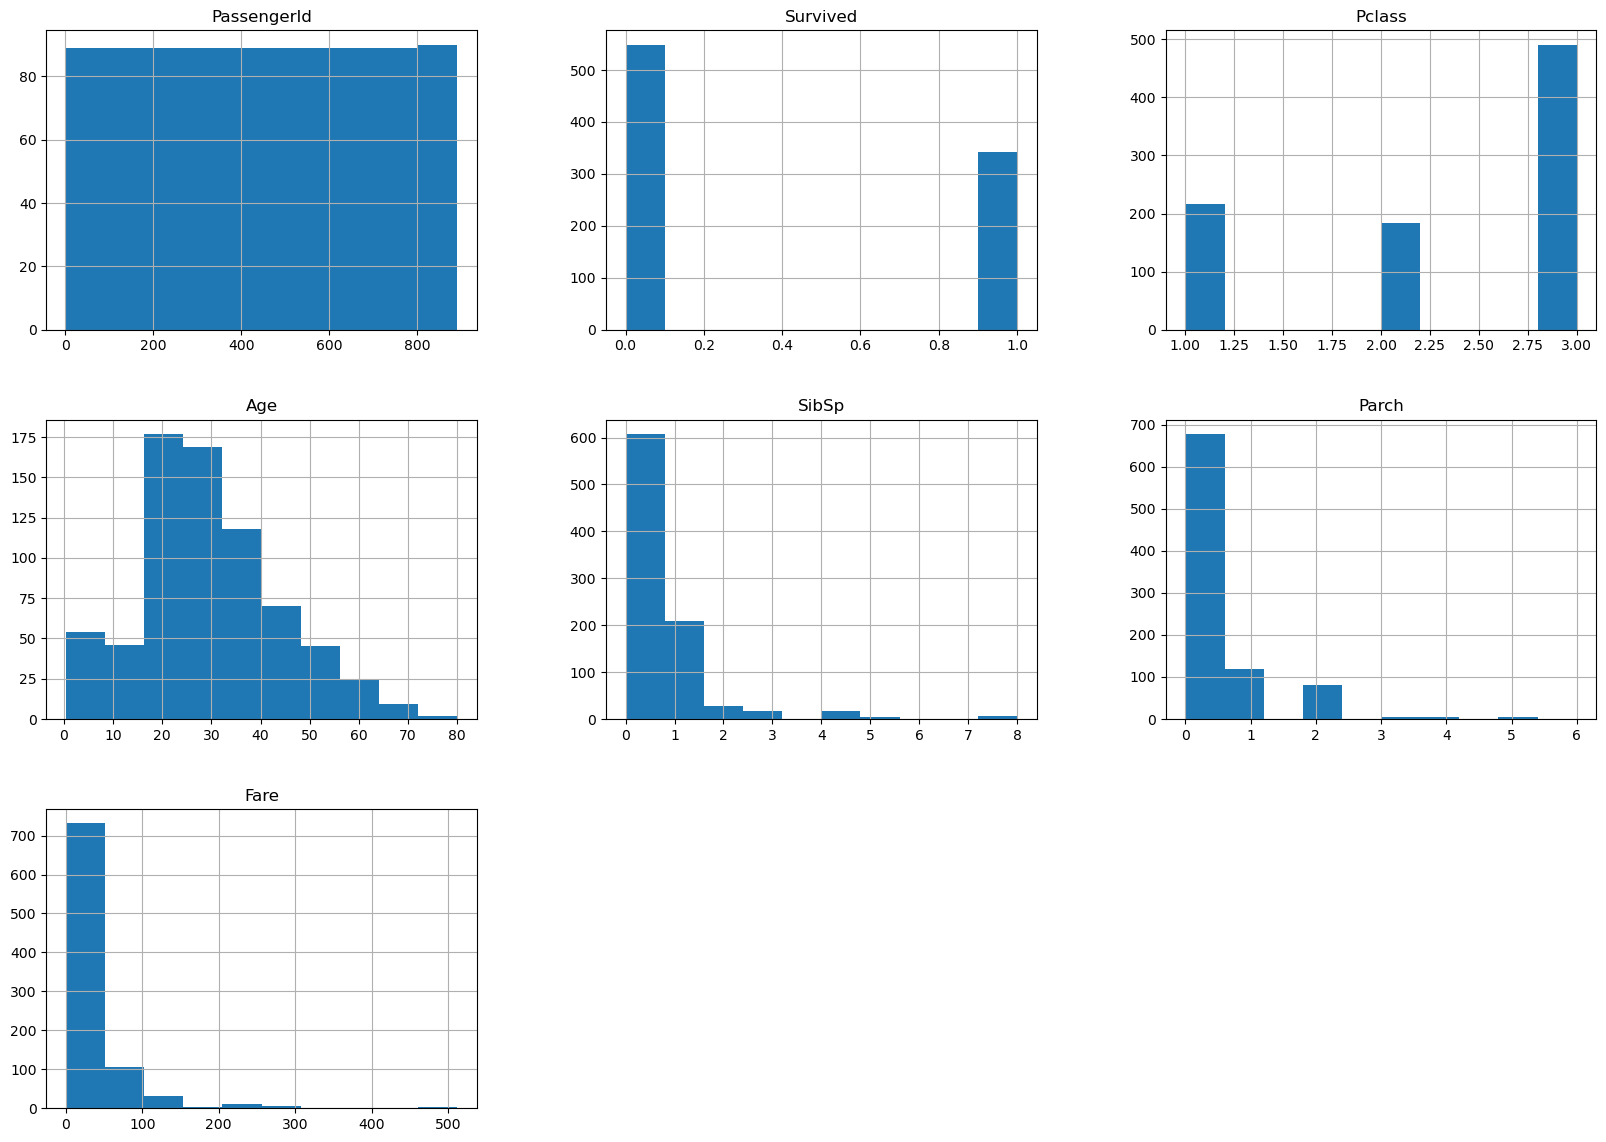

In [4]:
_ = titanic_dataset.hist(figsize=(20,14))

In [5]:
pd.crosstab(
    index=titanic_dataset["Survived"], columns=titanic_dataset["Sex"]
)

Sex,female,male
Survived,,
0,81,468
1,233,109


## Feature engineering

In [6]:
#Spotting the lacking values

titanic_dataset.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
#We choose to fix the age for the passengers concerned as the medium age.

median_age = titanic_dataset["Age"].median()

titanic_dataset["Age"] = titanic_dataset["Age"].fillna(median_age)

Then we discretize the continuous features "Age" and "Fare" into categorical groups in order to test hypotheses about their relationship with survival and other variables.

In [8]:
titanic_dataset["Age_groups"] = pd.cut(
    titanic_dataset["Age"],
    bins = [0, 15, 35, 60, 100],
    labels=["0-15", "15-35", "35-60", "60+"]
)

titanic_dataset["Age_groups"].value_counts()

Age_groups
15-35    591
35-60    195
0-15      83
60+       22
Name: count, dtype: int64

<Axes: xlabel='Age_groups'>

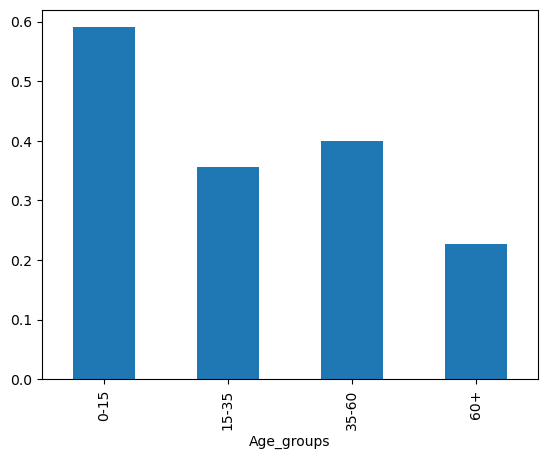

In [9]:
titanic_dataset.groupby("Age_groups", observed=True)["Survived"].mean().plot(kind="bar")

The features "Fare" and "Pclass" seem to be strongly correlated that's why we investigate the relationship between them to better understand feature redundancy before modeling.

In [10]:
titanic_dataset["Ticket_range"] = pd.cut(
    titanic_dataset["Fare"],
    bins = [0, 15, 50, 500],
    labels=["0£-15£", "15£-50£", "50£ +"]
)


titanic_dataset["Ticket_range"].value_counts()

#Ticket prices were grouped into categories (low, medium, high) to allow categorical analysis using Chi² tests.

Ticket_range
0£-15£     443
15£-50£    273
50£ +      157
Name: count, dtype: int64

In [11]:
pd.crosstab(
    index=titanic_dataset["Ticket_range"], columns=titanic_dataset["Survived"])

Survived,0,1
Ticket_range,,
0£-15£,330,113
15£-50£,154,119
50£ +,51,106


The survival rate is above 0.5 for the tickets which are more expensive than 50 pounds so this a good price to target survivors.

<Axes: xlabel='Ticket_range'>

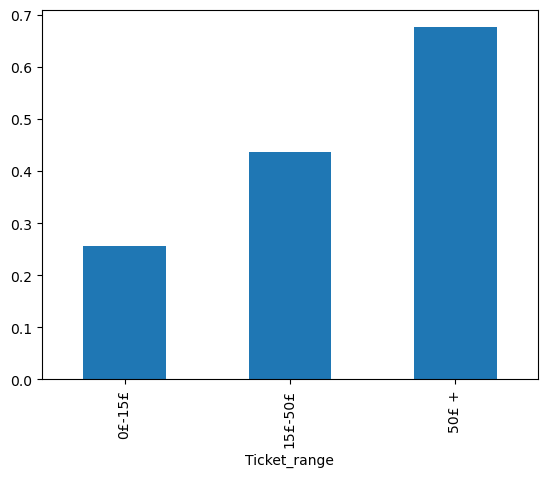

In [12]:
titanic_dataset.groupby("Ticket_range", observed=True)["Survived"].mean().plot(kind="bar")

In [13]:

class_ticket_prob = pd.crosstab(
    index=titanic_dataset["Pclass"], columns=titanic_dataset["Ticket_range"], normalize="index")
print()
print(class_ticket_prob)

#This shows the conditionnal probability : "If your class is X you paid your ticket as much"



Ticket_range    0£-15£   15£-50£     50£ +
Pclass                                    
1             0.004808  0.341346  0.653846
2             0.500000  0.460674  0.039326
3             0.724846  0.246407  0.028747


In [14]:
class_ticket = pd.crosstab(
    index=titanic_dataset["Pclass"], columns=titanic_dataset["Ticket_range"])
#contingency array without probabilities


from scipy.stats import chi2_contingency


n = class_ticket.sum().sum()
chi2 = chi2_contingency(class_ticket)[0]

r,k = class_ticket.shape

cramers_V = np.sqrt(chi2/ (n*(min(r,k)-1)))
print("The Cramer's coefficient is  :", cramers_V)

The Cramer's coefficient is  : 0.5404677875238253


Now we confirm that those features are strongly correlated (> 0.5) however for the study accuracy we aim to identify the most relevant price thresholds to classify the passengers in the different classes ont the ship.

To better understand how ticket price interacts with passenger class, we train a decision tree using both Fare and Pclass. This allows the model to learn class-dependent thresholds rather than applying a single global threshold.

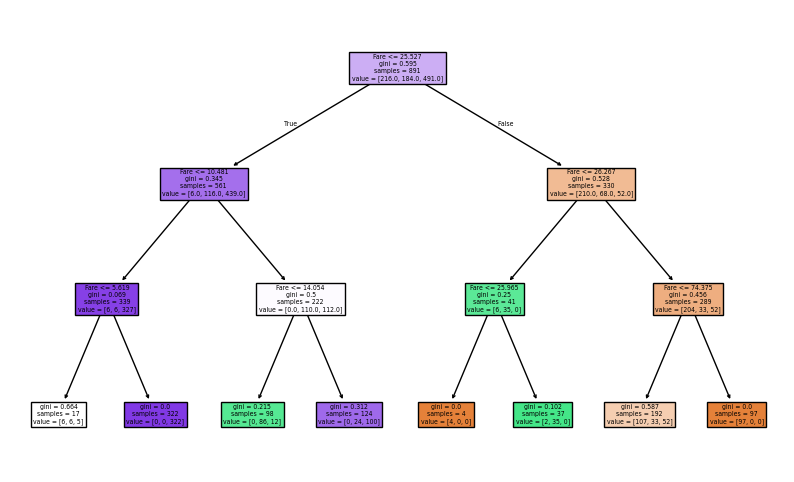

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

tree = DecisionTreeClassifier(max_depth=3)
tree.fit(titanic_dataset[["Fare"]], titanic_dataset["Pclass"])

plt.figure(figsize=(10,6))
plot_tree(tree, feature_names=["Fare"], filled=True)
plt.show()

The optimal ceils identified by our tree for the third and second class are respectively : 14.054£ and 23.965£. We don't fix a ceil price to the first class for obvious reasons.

In [16]:
#If we repeat the same statiscal operations whith those numbers.

titanic_dataset["Ticket_range_2"] = pd.cut(
    titanic_dataset["Fare"],
    bins = [0, 14.054, 23.965, 500],
    labels=["0£-14£", "14£-24£", "24£ +"]
)


class_ticket_prob = pd.crosstab(
    index=titanic_dataset["Pclass"], columns=titanic_dataset["Ticket_range_2"], normalize="index")
print()
print(class_ticket_prob)
print ()

class_ticket = pd.crosstab(
    index=titanic_dataset["Pclass"], columns=titanic_dataset["Ticket_range_2"])



from scipy.stats import chi2_contingency


n = class_ticket.sum().sum()
chi2 = chi2_contingency(class_ticket)[0]

r,k = class_ticket.shape

cramers_V = np.sqrt(chi2/ (n*(min(r,k)-1)))
print("The Cramer's coefficient is  :", cramers_V)


Ticket_range_2    0£-14£   14£-24£     24£ +
Pclass                                      
1               0.004808  0.000000  0.995192
2               0.483146  0.123596  0.393258
3               0.687885  0.180698  0.131417

The Cramer's coefficient is  : 0.5115329251784594


The decision tree is able to clearly separate first-class passengers based on fare, while second and third classes remain more mixed.
This suggests that although "Fare" and "Pclass" are related, "Fare" alone is not sufficient to fully distinguish between all classes. In particular, second and third class passengers exhibit more overlap in terms of ticket price.

The Cramer's coeffcient is also a bit less than the previous one but still above 0.5, this shows that the features remain strongly correlated even if we can't increase the correlation as much as we would.

Common hypothesis : 

 "Women and Children first" is an unofficial code of conduct and gender role whereby the lives of women and children were to be saved first in a life-threatening situation. That code was indeed respected on the Titanic as 74% of the women and 52% of the children on board were saved, but only 20% of the men. Then if we add the class, the data should show for example that the people who have the better survival rate are the women in first-class between 0 and 15 years old. 



In [17]:
#We create a new feature by combining the elements in the studied features.

titanic_dataset["Group"] = (
    titanic_dataset["Sex"] + "_" +
    titanic_dataset["Age_groups"].astype(str) + "_" +
    titanic_dataset["Pclass"].astype(str)
)

titanic_dataset["Group"].value_counts()

Group
male_15-35_3      271
female_15-35_3     99
male_15-35_2       69
male_35-60_1       54
female_15-35_1     53
male_15-35_1       53
female_15-35_2     46
male_35-60_3       44
female_35-60_1     36
female_0-15_3      30
male_0-15_3        28
male_35-60_2       27
female_35-60_2     20
female_35-60_3     14
male_60+_1         12
female_0-15_2      10
male_0-15_2         9
male_60+_3          4
male_60+_2          3
female_0-15_1       3
male_0-15_1         3
female_60+_1        2
female_60+_3        1
Name: count, dtype: int64

In [18]:
table = pd.crosstab(
    titanic_dataset["Group"],
    titanic_dataset["Survived"],
    normalize="index"
)

print(table)

Survived               0         1
Group                             
female_0-15_1   0.333333  0.666667
female_0-15_2   0.000000  1.000000
female_0-15_3   0.466667  0.533333
female_15-35_1  0.018868  0.981132
female_15-35_2  0.065217  0.934783
female_15-35_3  0.464646  0.535354
female_35-60_1  0.027778  0.972222
female_35-60_2  0.150000  0.850000
female_35-60_3  0.857143  0.142857
female_60+_1    0.000000  1.000000
female_60+_3    0.000000  1.000000
male_0-15_1     0.000000  1.000000
male_0-15_2     0.000000  1.000000
male_0-15_3     0.678571  0.321429
male_15-35_1    0.603774  0.396226
male_15-35_2    0.913043  0.086957
male_15-35_3    0.870849  0.129151
male_35-60_1    0.629630  0.370370
male_35-60_2    0.962963  0.037037
male_35-60_3    0.931818  0.068182
male_60+_1      0.916667  0.083333
male_60+_2      0.666667  0.333333
male_60+_3      1.000000  0.000000


As expected the female in the higher classes have strong survival rate among the passegers, childrens are overall more likely to survive too.
Grown men (15 years old and above) have the worst survival rates regardless of their class.

## Cleaning data before modeling

In [19]:
titanic_dataset.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Age_groups',
       'Ticket_range', 'Ticket_range_2', 'Group'],
      dtype='object')

The feature "Sex" is important but it is still from type string, we need to numerize it before training our models.

In [20]:
array = pd.crosstab(
    index=titanic_dataset["Sex"], columns=titanic_dataset["Survived"], normalize ="index")

print(array)

titanic_dataset["Sex"] = titanic_dataset["Sex"].map({
    "male": 10 * array.loc["male", 1], "female": 10 * array.loc["female", 1]  })


#We choose to fix the score for male and female regarding their respective survival rates.


Survived         0         1
Sex                         
female    0.257962  0.742038
male      0.811092  0.188908


In [21]:
target_name = "Survived"

target = titanic_dataset[target_name]

data = titanic_dataset.drop( columns= [target_name,"Age_groups","Ticket_range","Ticket_range_2",
                                       "Name","PassengerId","Cabin","Embarked","Ticket", "Group"] )

#Removing irrevelant and redundant data.

## Modelisation 

In this part we will study differents model to compare their provided accuracy and theirs potential bias. 
We deliberately avoid using a linear regression here as the targeted variable which is boolean, does not fit with it.

Therefore, we will study the following models :


- 1- K-Nearest Neighbors (KNN)

- 2- LogisticRegression

- 3- Random Forest

## 1- KNN 

To determine the K number which provide the best accuracy for this model, we're goingo to train a KNN model multiple times with different values of K.

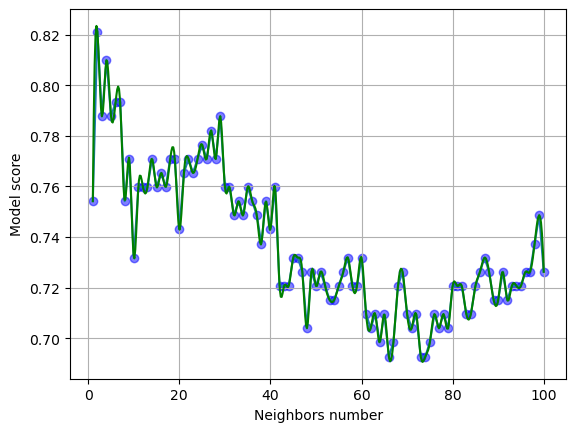

In [22]:
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split

from scipy.interpolate import make_interp_spline

x_train, x_test, y_train, y_test = train_test_split(data, target, test_size=0.2)

x= [ n for n in range(1,101) ]

y = []
for k in range (1,101) :
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train, y_train)
    y.append(model.score(x_test,y_test))

plt.xlabel("Neighbors number")

plt.ylabel("Model score")

plt.plot(x, y)

x_np = np.array(x)
y_np = np.array(y)

xnew = np.linspace(x_np.min(), x_np.max(), 500)
spl = make_interp_spline(x_np, y_np, k=3)
y_smooth = spl(xnew)

plt.plot(xnew, y_smooth, color = 'green')
plt.scatter(x, y, color= 'blue', alpha = 0.5)

plt.grid(True)


The curve obtained by this first method presents some irregularities. Because the function it describes is not defined on a continuous interval and also because the train, split data is a method of compromise.
The goal of a such method is to limit near values from the train data in the test data in order to reduce bias and noise. The problem encountered is that this split is random and the data targeted to been avoid could be much in the train data.

One of the possible methods is to train our model a several times and the take the mean score.

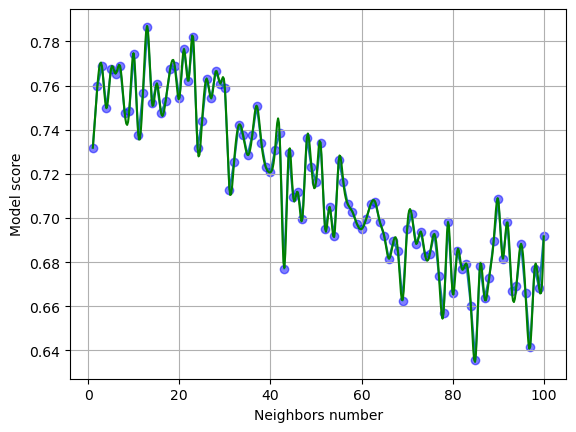

In [23]:

x= [ n for n in range(1,101) ]

y = []
for k in range (1,101) :
    temp_y = []
    for j in range(5):
        x_train, x_test, y_train, y_test = train_test_split(data, target, test_size=0.2)
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(x_train, y_train)
        temp_y.append(model.score(x_test,y_test))
    y.append(np.mean(temp_y))

plt.xlabel("Neighbors number")

plt.ylabel("Model score")

plt.plot(x, y)

x_np = np.array(x)
y_np = np.array(y)

xnew = np.linspace(x_np.min(), x_np.max(), 500)
spl = make_interp_spline(x_np, y_np, k=3)
y_smooth = spl(xnew)

plt.plot(xnew, y_smooth, color = 'green')
plt.scatter(x, y, color= 'blue', alpha = 0.5)

plt.grid(True)

It doesn't solve our problem at all, the noise has even been increased. It suggests that this transformation does not improve the structure of the data.
It may indicate that the chosen grouping is not optimal or that the relationship between these variables is more complex than expected.


Another method is the cross val score methode, the idea is to split the data in n pieces (usually n=5) , choose one of them as the target, train our model with all the other parts and take the mean score.

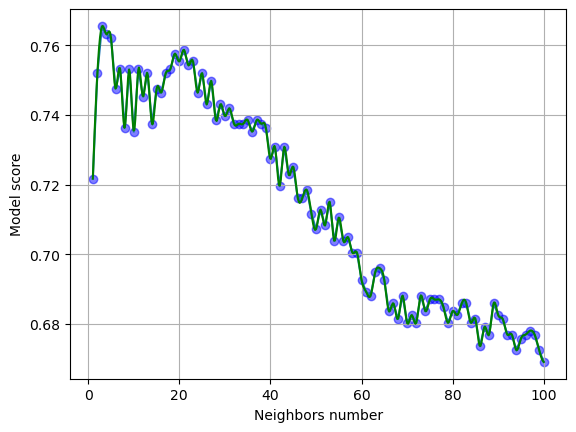

In [24]:
from sklearn.model_selection import cross_val_score

x= [ n for n in range(1,101) ]
y = []

for k in range (1,101) :
    model = KNeighborsClassifier(n_neighbors = k)
    model_scores = cross_val_score (model, data, target, cv=5)
    y.append(np.mean(model_scores))

plt.xlabel("Neighbors number")

plt.ylabel("Model score")

plt.plot(x, y)

x_np = np.array(x)
y_np = np.array(y)

xnew = np.linspace(x_np.min(), x_np.max(), 500)
spl = make_interp_spline(x_np, y_np, k=3)
y_smooth = spl(xnew)

plt.plot(xnew, y_smooth, color = 'green')
plt.scatter(x, y, color= 'blue', alpha = 0.5)

plt.grid(True)



The use of cross-validation helps to reduce the variance of the score estimation and reveals a more stable trend, highlighting the bias-variance trade-off of the KNN model.

For this model, the optimal value of K appears to lie aroud 20, although the accuracy is higher with K=1, this likely reflects overfitting rather than true model performance..

## 2- Logistic Regression

In [25]:
#Basic method

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

data_train, data_test, target_train, target_test = train_test_split(data, target, test_size=0.2)

model.fit(data_train, target_train)

accuracy = model.score(data_test, target_test)

print(f" The accuracy of the model is {accuracy} ")


 The accuracy of the model is 0.770949720670391 


In [26]:
#Cross validation

model_scores = cross_val_score(model, data, target, cv=5)
print(f"The cvv method provides a model score of : {np.mean(model_scores)} ")

The cvv method provides a model score of : 0.7856317870817903 


In [27]:
for feature, coef in zip(data.columns, model.coef_.ravel() ):
    print(f"{feature}'s coefficient : {coef}")

Pclass's coefficient : -1.1144740017722865
Sex's coefficient : 0.5152336286331793
Age's coefficient : -0.04595262158685397
SibSp's coefficient : -0.35857842829346187
Parch's coefficient : -0.05498095475004542
Fare's coefficient : 0.003337727383315581


The most revelant coefficients according to this model, are in descending order : "Sex", "Parch", "Sibsp", "Plcass". 
If the feature have a negative coeffcient it means that a low value of it increases significatly the chances of the person dies, whereas a high coefficent increase in opposite the chances of survival.

In our case, being a woman on the boat is correlated with survival when sailing accross in third class is strongly correlated with death.Traveling with your family ("SibSp", "Parch") is it as well, probably because being with your relatives could reduce your autonomy and delay the essential actions in a situation of crisis.

Furthermore "Fare" and "Pclass" do not present close coefficient values, which substantiates our previous analysis about potential redundant values.
    

## Confusion matrix

A confusion matrix is a matrix in which the coefficient are the numbers of (False/True pred and False/True test). 

A such vector suits very well our two outcomes problem by its simple structure 2 rows and 2 columns. It compare the target values and what the model predict for them, allowing us to analyze the survival rate and death rate which might be different.

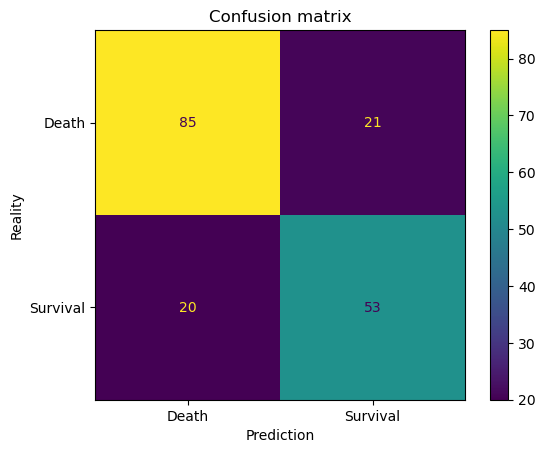

Model accuracy to survival : 0.726027397260274
Model accuracy to death : 0.8018867924528302


In [28]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

data_pred = model.predict(data_test)

cm = confusion_matrix(target_test, data_pred)

labels = ["Death", "Survival"]


#Printing our matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format='d') 

plt.xlabel("Prediction")
plt.ylabel("Reality")
plt.title("Confusion matrix")
plt.show()





FN=cm[1,0]
TP=cm[1,1]
TN=cm[0,0]
FP=cm[0,1]

accuracy_surv = TP / (TP+FN)

accuracy_dead = TN / (TN+FP)


print(f"Model accuracy to survival : {accuracy_surv}")

print(f"Model accuracy to death : {accuracy_dead}")


It highlights that the model is more accurate when it comes to death instead of survival, which is a major info. It could be explain by the fact that there is more negative coefficients than positive and that one of them, "Pclass" overcomes all other coeffcient in absolute value. 

Even if the logistic regression fits more in this context than linear regression, a drawback of this method remains the default threshold which is fixed to 0.5.
As this model is death oriented rather than survival, it might be very useful to find the intersection point curves where the threshold give the best compromise between survival and death accuracy.


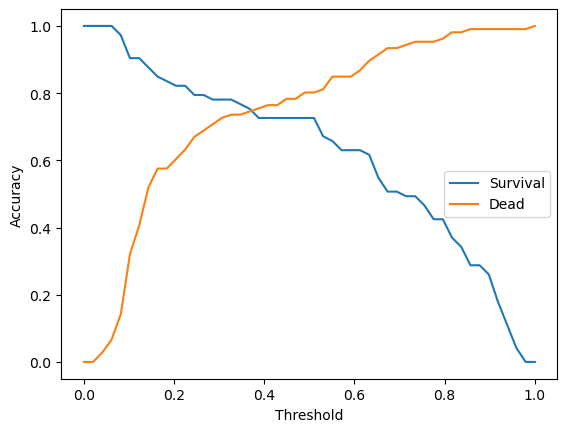

In [29]:

data_proba=model.predict_proba(data_test)[:,1]

threshold=np.linspace(0, 1, 50)

survived=[]

for t in threshold:
    data_pred = (data_proba >= t).astype(int)
    
    N=confusion_matrix(target_test, data_pred)

    
    FN=N[1,0]
    TP=N[1,1]

    accuracy_surv = TP / (TP+FN)

    survived.append(accuracy_surv)

dead=[]

for t in threshold:
    data_pred = (data_proba >= t).astype(int)
    
    N=confusion_matrix(target_test, data_pred)


    TN=N[0,0]
    FP=N[0,1]
    
    accuracy_dead = TN / (TN+FP)

    dead.append(accuracy_dead)


plt.xlabel("Threshold")
plt.ylabel("Accuracy")

plt.plot(threshold, survived, label='Survival')

plt.plot(threshold, dead, label='Dead')

plt.legend()



The analysis of accuracy as a function of the threshold shows an intersection point between 0.3 and 0.4 regarding the test, indicating a trade-off between the detection of survivors and non-survivors. 

This threshold differs from the default value (0.5), suggesting that it is not optimal for this imbalanced problem.

## 3- Random Forest

We have already train a Decision tree Classifier in the feature engineering part, now we will train a forest of such trees with more parameters, in order to get a better comprehension of how the variables interract between each other.

A decision tree provides an interpretable model but tends to overfit, while a random forest improves performance by combining multiple trees and reducing variance.

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model= RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(data_train, target_train)

rf_score=rf_model.score(data_test, target_test)


print(f"Global score : {rf_score}")
print()

data_pred = rf_model.predict(data_test)

cm = confusion_matrix(target_test, data_pred)

FN=cm[1,0]
TP=cm[1,1]
TN=cm[0,0]
FP=cm[0,1]

accuracy_surv = TP / (TP+FN)

accuracy_dead = TN / (TN+FP)


print(f"Model accuracy to survival : {accuracy_surv}")
print()
print(f"Model accuracy to death : {accuracy_dead}")
print()
for feature, imp in zip(data.columns, rf_model.feature_importances_.ravel() ):
    print(f" Importance of {feature}: {imp}")


Global score : 0.7541899441340782

Model accuracy to survival : 0.6986301369863014

Model accuracy to death : 0.7924528301886793

 Importance of Pclass: 0.0833738818854237
 Importance of Sex: 0.2761603985083422
 Importance of Age: 0.25914366407277906
 Importance of SibSp: 0.05013530100189885
 Importance of Parch: 0.04086418168719867
 Importance of Fare: 0.2903225728443576


This method highlights the importance of the "Age" feature, which seems to be less effectively captured by the logistic regression model. We also notice that this model identified the feature "Fare" as more revelant than "Pclass", contrary to the result of the previous model.

The coefficients obtained from logistic regression cannot be directly compared to the feature importances of a random forest, as the two models capture relationships in fundamentally different ways.

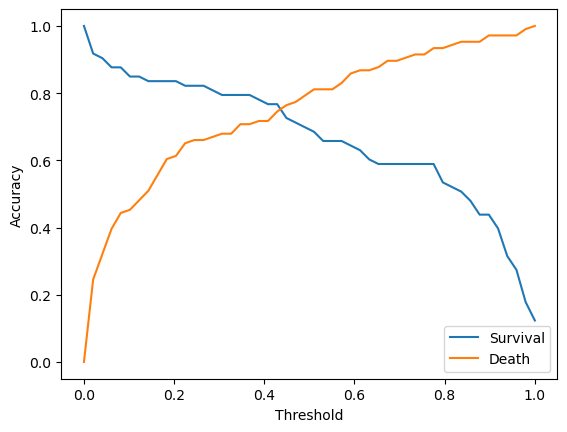

In [31]:
#Let's resume our threshold analysis

data_proba=rf_model.predict_proba(data_test)[:,1]

threshold=np.linspace(0, 1, 50)

survived=[]

for t in threshold:
    data_pred = (data_proba >= t).astype(int)
    
    N=confusion_matrix(target_test, data_pred)

    
    FN=N[1,0]
    TP=N[1,1]

    accuracy_survie = TP / (TP+FN)

    survived.append(accuracy_survie)

dead=[]

for t in threshold:
    data_pred = (data_proba >= t).astype(int)
    
    N=confusion_matrix(target_test, data_pred)


    TN=N[0,0]
    FP=N[0,1]
    
    accuracy_mort = TN / (TN+FP)

    dead.append(accuracy_mort)


plt.xlabel("Threshold")
plt.ylabel("Accuracy")

plt.plot(threshold, survived, label='Survival')

plt.plot(threshold, dead, label='Death')

plt.legend()

In [32]:
#Let's using Cross validation score again to reduce noise.


from sklearn.model_selection import cross_val_predict

model_scores = cross_val_score (rf_model, data, target, cv=5)

score =(np.mean(model_scores))

print(f"Global score : {score}")
print()


data_pred = cross_val_predict(rf_model, data, target, cv=5)

cm = confusion_matrix(target, data_pred)

FN=cm[1,0]
TP=cm[1,1]
TN=cm[0,0]
FP=cm[0,1]

accuracy_surv = TP / (TP+FN)

accuracy_dead = TN / (TN+FP)


print(f"Model accuracy to survival : {accuracy_surv}")
print()
print(f"Model accuracy to death : {accuracy_dead}")
print()


Global score : 0.8148703785073128

Model accuracy to survival : 0.7280701754385965

Model accuracy to death : 0.8688524590163934



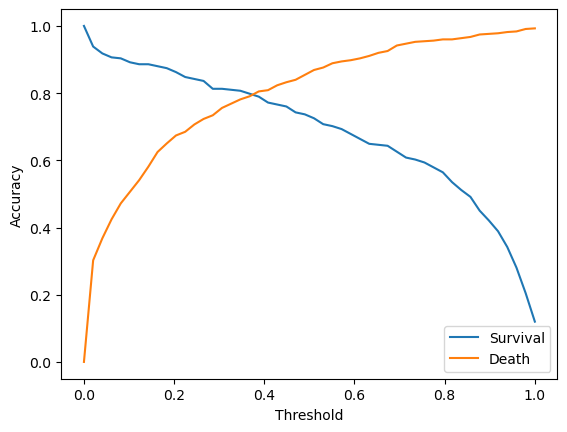

In [33]:
#Same based-threshold analysis

data_proba=cross_val_predict(rf_model, data, target, cv=5, method="predict_proba")[:,1]

seuil=np.linspace(0, 1, 50)

survived=[]

for t in seuil:
    data_pred = (data_proba >= t).astype(int)
    
    N=confusion_matrix(target, data_pred)

    
    FN=N[1,0]
    TP=N[1,1]

    accuracy_survie = TP / (TP+FN)

    survived.append(accuracy_survie)

dead=[]

for t in seuil:
    data_pred = (data_proba >= t).astype(int)
    
    N=confusion_matrix(target, data_pred)


    TN=N[0,0]
    FP=N[0,1]
    
    accuracy_mort = TN / (TN+FP)

    dead.append(accuracy_mort)


plt.xlabel("Threshold")
plt.ylabel("Accuracy")

plt.plot(seuil, survived, label='Survival')

plt.plot(seuil, dead, label='Death')

plt.legend()

The optimal threshold for the random forest is this time around 0.38, which balances the prediction of survivors and non-survivors.
This means that the model often assigns lower probabilities to survivors, so a lower threshold is needed to detect them.

## Statistical analysis

To further investigate the relationship between each feature and survival, we perform a Chi-squared test of independence.
This test allows us to determine whether there is a statistically significant association between each variable and the target variable.

In [34]:
variables = ["Sex", "Pclass", "Age", "Fare", "SibSp", "Parch"]

for var in variables:
    table = pd.crosstab(titanic_dataset[var], titanic_dataset["Survived"])
    chi2, p, _, _ = chi2_contingency(table)
    print(f"{var} → p-value = {p}")

Sex → p-value = 1.1973570627755645e-58
Pclass → p-value = 4.549251711298793e-23
Age → p-value = 0.028588492552294256
Fare → p-value = 1.1647635739939964e-11
SibSp → p-value = 1.5585810465902147e-06
Parch → p-value = 9.703526421039997e-05


All variables show very low p-values, indicating that their relationship with survival is statistically significant.

In particular, Sex and Pclass exhibit extremely low p-values, suggesting a very strong association with survival. This is consistent with the well-known influence of gender and social class on survival rates.
Fare also shows a strong association, which is expected as it reflects socio-economic status and is closely related to passenger class.
Age presents a higher p-value compared to other variables, although it remains statistically significant. This suggests that its relationship with survival may be more complex or less direct.

Finally, SibSp and Parch also show significant associations, indicating that family structure may have played a role in survival outcomes.

However, while the p-values indicate statistically significant relationships, they do not measure the strength or direction of these associations.
Overall, this analysis confirms that all selected features are relevant for predicting survival, although their influence may vary in strength and complexity.

In [35]:
corr = data.corr(numeric_only=True)
print(corr)

          Pclass       Sex       Age     SibSp     Parch      Fare
Pclass  1.000000 -0.131900 -0.339898  0.083081  0.018443 -0.549500
Sex    -0.131900  1.000000 -0.081163  0.114631  0.245489  0.182333
Age    -0.339898 -0.081163  1.000000 -0.233296 -0.172482  0.096688
SibSp   0.083081  0.114631 -0.233296  1.000000  0.414838  0.159651
Parch   0.018443  0.245489 -0.172482  0.414838  1.000000  0.216225
Fare   -0.549500  0.182333  0.096688  0.159651  0.216225  1.000000


While correlation analysis may appear limited, investigating interactions between features can reveal hidden patterns that may improve model performance.

In [36]:
corr = pd.concat([data, titanic_dataset["Survived"]], axis=1).corr(numeric_only=True)
corr["Survived"].sort_values()

Pclass     -0.338481
Age        -0.064910
SibSp      -0.035322
Parch       0.081629
Fare        0.257307
Sex         0.543351
Survived    1.000000
Name: Survived, dtype: float64

The Pearson correlation coefficient measures linear relationships between numerical variables.
While some features show moderate correlation with survival, this measure may fail to capture more complex or non-linear patterns in the data.

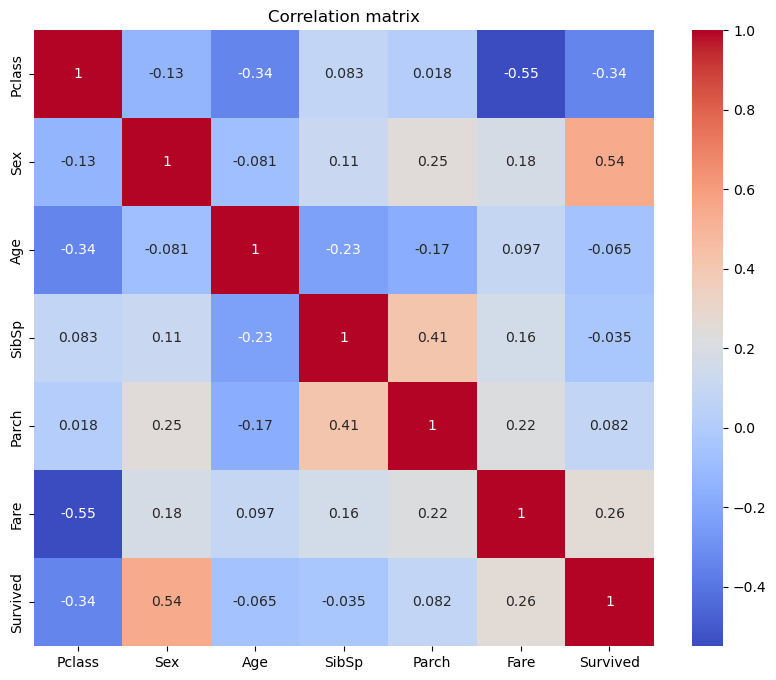

In [37]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation matrix")
plt.show()

## Conclusion

This project combined statistical analysis and machine learning to study the factors influencing survival on the Titanic.
While statistical methods highlighted key relationships between variables, they remained limited in capturing complex patterns. Machine learning models, particularly random forest, provided a more flexible approach and revealed non-linear interactions between features.
We also showed that modify threshold can significantly improve classification balance, especially in an imbalanced context.
Overall, this analysis emphasizes the importance of using complementary approaches to better understand data and improve predictive performance.